# Modality Ablation Study: Metric, Log, and Visual (VLM) — Alone, in Pairs, and All Three

a performance evaluation showing what changes when the modalities are used **alone**, **in pairs**, and **all three together**.

We evaluate all $2^3-1=7$ non-empty subsets of {Metric, Log, Visual}:

| Combination | Symbol |
|---|---|
| Metric only | $M$ |
| Log only (level counts/ratios + TF-IDF) | $L$ |
| Visual only (VLM) | $V$ |
| Metric + Log | $M{+}L$ |
| Metric + Visual | $M{+}V$ |
| Log + Visual | $L{+}V$ |
| Metric + Log + Visual | $M{+}L{+}V$ |

**Two evaluation tiers, clearly labeled, so nothing is overstated:**
- $M$, $L$, $M{+}L$ involve no VLM call, so they are evaluated on the **full 2,000-sample
  test split** — a statistically robust number, directly comparable to the paper's
  Table 6/8.
- $V$, $M{+}V$, $L{+}V$, $M{+}L{+}V$ require a VLM verdict per sample. To respect the
  Gemini free-tier daily quota, we **reuse** the 9 test-split VLM verdicts already
  collected and saved in `results/trimodal_fusion_results.csv`
  (`08_trimodal_fusion.ipynb`) rather than issuing new API calls — so these four rows are
  a small ($n=9$) but genuine, leakage-free, real-API result.

**Fusion rule.** For combinations without a jointly-trained model (anything involving
$V$), we use simple equal-weight score averaging:

$$
P_{A+B} = 0.5\cdot P_A + 0.5\cdot P_B, \qquad
P_{M+L+V} = 0.5\cdot P_{M+L} + 0.5\cdot P_V
$$

thresholded at $0.5$. $M$, $L$, and $M{+}L$ instead use a single **jointly-trained**
Random Forest per combination (the standard way to fuse tabular modalities), since that is
strictly stronger than post-hoc averaging when a joint model is trainable.


## 1 — Environment Setup

Same requirements as the previous two notebooks (`scikit-learn`, `google-generativeai`,
`python-dotenv`, `pillow`, `requests`). No new Gemini API calls are made in this
notebook — the visual scores are reloaded from
`results/trimodal_fusion_results.csv`.


In [1]:
import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import csr_matrix, hstack, issparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

warnings.filterwarnings('ignore')
sys.path.insert(0, r"d:\multimodal-rca-engine")

from dotenv import load_dotenv
load_dotenv(Path(r"d:\multimodal-rca-engine\.env"))

from models.data_loader import MultimodalDataLoader

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROJECT_DIR = Path(r"d:\multimodal-rca-engine")
DATASET_DIR = PROJECT_DIR / "data" / "multimodal_dataset"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RF_PARAMS = dict(n_estimators=200, max_depth=20, min_samples_split=5,
                  class_weight="balanced", random_state=42, n_jobs=-1)

print("Libraries loaded.")


Libraries loaded.


## 2 — Rebuild the Same Train / Val / Test Split

Identical loader configuration (`seed=42`) and split (`test_size=0.2`, `val_size=0.1`,
`random_state=42`) as `08_trimodal_fusion.ipynb`, so the test split — and therefore the
9 VLM-evaluated samples — line up exactly with the saved CSV.


In [2]:
loader = MultimodalDataLoader(dataset_dir=DATASET_DIR, noise_level=0.15, feature_dropout=0.05, seed=42)
loader.load_metadata()
data = loader.build_feature_matrix(max_samples=10000, include_tfidf=True)
splits = loader.split_data(data, test_size=0.2, val_size=0.1, random_state=42)
print(f"Test split size: {len(splits['test']['sample_ids']):,}")


 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000

 Building feature matrix for 10,000 samples...


   Processed 2,000/10,000 samples...


   Processed 4,000/10,000 samples...


   Processed 6,000/10,000 samples...


   Processed 8,000/10,000 samples...


   Processed 10,000/10,000 samples...
    Extracted features for 10,000 samples (skipped 0)


    Applying noise (level=0.15, dropout=0.05)...
    Building TF-IDF matrix...


      TF-IDF shape: (10000, 100)
    y_root_cause: 6 classes → [np.str_('config'), np.str_('hardware'), np.str_('network'), np.str_('none'), np.str_('resource'), np.str_('software')]
    y_severity: 4 classes → [np.str_('critical'), np.str_('high'), np.str_('medium'), np.str_('none')]
    y_layer: 11 classes → [np.str_('application'), np.str_('cdn'), np.str_('database'), np.str_('firewall'), np.str_('kubernetes_deployments'), np.str_('kubernetes_ingress'), np.str_('linux_host'), np.str_('linux_vm'), np.str_('network'), np.str_('proxy'), np.str_('storage')]
    y_scenario: 23 classes → [np.str_('APP_001'), np.str_('APP_002'), np.str_('CDN_001'), np.str_('CDN_002'), np.str_('DB_001'), np.str_('DB_002'), np.str_('FW_001'), np.str_('FW_002'), np.str_('HOST_001'), np.str_('HOST_002'), np.str_('K8D_001'), np.str_('K8D_002'), np.str_('K8I_001'), np.str_('K8I_002'), np.str_('NET_001'), np.str_('NET_002'), np.str_('PRX_001'), np.str_('PRX_002'), np.str_('STR_001'), np.str_('STR_002'), np.str_('

## 3 — Train Three Tabular Variants: Metric-only, Log-only, Metric+Log

Each variant is a fresh Random Forest with the same hyperparameters as
`models/rca_models.py::AnomalyDetector`, differing only in which feature block(s) it
sees. This directly isolates each tabular modality's standalone contribution.


In [ ]:
def build_X(split, feature_set):
    blocks = []
    if "metric" in feature_set:
        blocks.append(split["X_metrics"].values)
    if "log" in feature_set:
        blocks.append(split["X_logs"].values)
    dense = np.hstack(blocks) if len(blocks) > 1 else blocks[0]
    if "log" in feature_set and split.get("X_tfidf") is not None:
        return hstack([csr_matrix(dense), split["X_tfidf"]])
    return dense

def train_variant(feature_set):
    X_train = build_X(splits["train"], feature_set)
    y_train = splits["train"]["y_anomaly"]
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_train, y_train)
    return model

variants = {}
for name, fset in [("M", {"metric"}), ("L", {"log"}), ("M+L", {"metric", "log"})]:
    print(f"Training variant {name} ({fset})...")
    variants[name] = train_variant(fset)
print("\nDone.")


Training variant M ({'metric'})...


Training variant L ({'log'})...


Training variant M+L ({'metric', 'log'})...



Done.


## 4 — Reload the Previously Computed VLM (Gemini) Scores

Reusing `results/trimodal_fusion_results.csv` from `08_trimodal_fusion.ipynb` — no new
Gemini calls, respecting the daily quota.


In [4]:
fusion_csv = RESULTS_DIR / "trimodal_fusion_results.csv"
vlm_df = pd.read_csv(fusion_csv)[["sample_id", "is_anomaly", "visual_status", "visual_confidence"]]

test_id_set = set(splits["test"]["sample_ids"])
assert vlm_df["sample_id"].isin(test_id_set).all(), "VLM sample(s) not found in the current test split!"

vlm_df["P_V"] = vlm_df["visual_confidence"] * (vlm_df["visual_status"] == "ANOMALY").astype(float)
print(f"Reloaded {len(vlm_df)} VLM-evaluated test-split samples (0 new API calls).")
vlm_df


Reloaded 9 VLM-evaluated test-split samples (0 new API calls).


,sample_id,is_anomaly,visual_status,visual_confidence,P_V
0,sample_003963,0,NORMAL,0.98,0.00
1,sample_002361,0,NORMAL,0.95,0.00
2,sample_000302,0,NORMAL,0.98,0.00
3,sample_000992,0,NORMAL,0.98,0.00
4,sample_006313,1,ANOMALY,0.95,0.95
5,sample_006653,1,ANOMALY,1.00,1.00
6,sample_006527,1,ANOMALY,1.00,1.00
7,sample_009873,1,ANOMALY,1.00,1.00
8,sample_007227,1,ANOMALY,1.00,1.00


## 5 — Compute Modality-Specific Scores for the Same 9 Samples

For each trained tabular variant, we slice its own feature space down to the 9
VLM-evaluated `sample_id`s (same leak-free out-of-sample slicing as the fusion notebook)
and get $P_M(x)$, $P_L(x)$, $P_{M+L}(x)$.


In [ ]:
def build_mini_split(full_split, wanted_ids):
    id_to_pos = {sid: i for i, sid in enumerate(full_split["sample_ids"])}
    positions = [id_to_pos[sid] for sid in wanted_ids]
    mini = {
        "X_metrics": full_split["X_metrics"].iloc[positions].reset_index(drop=True),
        "X_logs": full_split["X_logs"].iloc[positions].reset_index(drop=True),
        "y_anomaly": full_split["y_anomaly"][positions],
        "sample_ids": [full_split["sample_ids"][p] for p in positions],
    }
    if full_split.get("X_tfidf") is not None:
        mini["X_tfidf"] = full_split["X_tfidf"][positions]
    return mini

wanted_ids = vlm_df["sample_id"].tolist()
mini_split = build_mini_split(splits["test"], wanted_ids)

scores = vlm_df.copy()
for name, fset in [("M", {"metric"}), ("L", {"log"}), ("M+L", {"metric", "log"})]:
    X_mini = build_X(mini_split, fset)
    scores[f"P_{name.replace('+', '')}"] = variants[name].predict_proba(X_mini)[:, 1]

scores = scores.rename(columns={"P_ML": "P_ML_combo"})  # avoid clashing with earlier P_ML naming
scores[["sample_id", "is_anomaly", "P_M", "P_L", "P_ML_combo", "P_V"]]


,sample_id,is_anomaly,P_M,P_L,P_ML_combo,P_V
0,sample_003963,0,0.058825,0.019514,0.005013,0.00
1,sample_002361,0,0.293364,0.000000,0.002509,0.00
2,sample_000302,0,0.164442,0.011667,0.016677,0.00
3,sample_000992,0,0.099173,0.000000,0.000028,0.00
4,sample_006313,1,0.953333,0.810209,0.832286,0.95
5,sample_006653,1,0.411980,0.981500,0.965833,1.00
6,sample_006527,1,0.821391,0.993167,0.975833,1.00
7,sample_009873,1,0.336133,1.000000,0.997333,1.00
8,sample_007227,1,0.706745,0.995000,0.975786,1.00


## 6 — All 7 Modality Combinations on the 9-Sample VLM Subset

Equal-weight score fusion for any pair/triple involving $V$; the jointly-trained model's
own probability for $M$, $L$, $M{+}L$.


In [6]:
y_true_small = scores["is_anomaly"].values

def f1_acc(y_true, p, threshold=0.5):
    y_pred = (p >= threshold).astype(int)
    return {
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

combo_scores = {
    "M":       scores["P_M"].values,
    "L":       scores["P_L"].values,
    "V":       scores["P_V"].values,
    "M+L":     scores["P_ML_combo"].values,
    "M+V":     0.5 * scores["P_M"].values   + 0.5 * scores["P_V"].values,
    "L+V":     0.5 * scores["P_L"].values   + 0.5 * scores["P_V"].values,
    "M+L+V":   0.5 * scores["P_ML_combo"].values + 0.5 * scores["P_V"].values,
}

ablation_small = []
for combo, p in combo_scores.items():
    row = {"combination": combo, "n_samples": len(y_true_small)}
    row.update(f1_acc(y_true_small, p))
    ablation_small.append(row)
ablation_small_df = pd.DataFrame(ablation_small).set_index("combination").round(3)
ablation_small_df


,n_samples,f1,precision,recall,accuracy
combination,,,,,
M,9,0.75,1.0,0.6,0.778
L,9,1.00,1.0,1.0,1.000
V,9,1.00,1.0,1.0,1.000
M+L,9,1.00,1.0,1.0,1.000
M+V,9,1.00,1.0,1.0,1.000
L+V,9,1.00,1.0,1.0,1.000
M+L+V,9,1.00,1.0,1.0,1.000


## 7 — Full-Test-Set Ablation for the Tabular-Only Combinations ($N=2{,}000$)

For $M$, $L$, and $M{+}L$ — the combinations that need no VLM call — we can afford the
statistically robust full test split.


In [7]:
y_true_full = splits["test"]["y_anomaly"]

ablation_full = []
for name, fset in [("M", {"metric"}), ("L", {"log"}), ("M+L", {"metric", "log"})]:
    X_test = build_X(splits["test"], fset)
    p_test = variants[name].predict_proba(X_test)[:, 1]
    row = {"combination": name, "n_samples": len(y_true_full)}
    row.update(f1_acc(y_true_full, p_test))
    ablation_full.append(row)
ablation_full_df = pd.DataFrame(ablation_full).set_index("combination").round(4)
ablation_full_df


,n_samples,f1,precision,recall,accuracy
combination,,,,,
M,2000,0.9333,0.9658,0.903,0.9355
L,2000,0.9774,0.9809,0.974,0.9775
M+L,2000,0.9860,0.9850,0.987,0.9860


## 8 — Results: Bar Chart Across All 7 Combinations


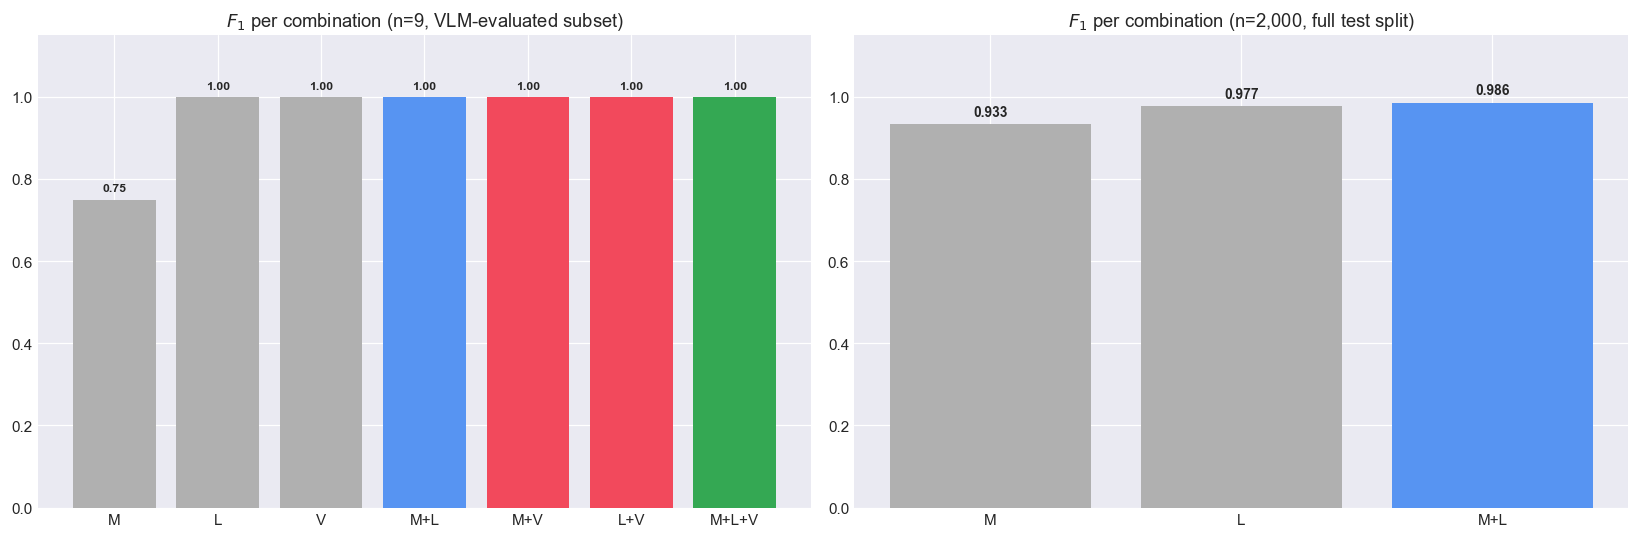

Figure saved to d:\multimodal-rca-engine\results\figures\modality_ablation.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = ["M", "L", "V", "M+L", "M+V", "L+V", "M+L+V"]
colors = []
for c in order:
    parts = set(c.split("+"))
    if parts == {"M", "L", "V"}:
        colors.append("#34a853")       
    elif "V" in parts and len(parts) == 2:
        colors.append("#f2495c")   
    elif parts == {"M", "L"}:
        colors.append("#5794f2")      
    else:
        colors.append("#b0b0b0")      

axes[0].bar(order, [ablation_small_df.loc[c, "f1"] for c in order], color=colors)
axes[0].set_title(f"$F_1$ per combination (n={ablation_small_df['n_samples'].iloc[0]}, VLM-evaluated subset)")
axes[0].set_ylim(0, 1.15)
for i, c in enumerate(order):
    axes[0].text(i, ablation_small_df.loc[c, "f1"] + 0.02, f"{ablation_small_df.loc[c,'f1']:.2f}",
                 ha="center", fontsize=8, fontweight="bold")

full_order = ["M", "L", "M+L"]
axes[1].bar(full_order, [ablation_full_df.loc[c, "f1"] for c in full_order],
            color=["#b0b0b0", "#b0b0b0", "#5794f2"])
axes[1].set_title(f"$F_1$ per combination (n={ablation_full_df['n_samples'].iloc[0]:,}, full test split)")
axes[1].set_ylim(0, 1.15)
for i, c in enumerate(full_order):
    axes[1].text(i, ablation_full_df.loc[c, "f1"] + 0.02, f"{ablation_full_df.loc[c,'f1']:.3f}",
                 ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
fig_path = RESULTS_DIR / "figures" / "modality_ablation.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")


## 9 — What Changes When Modalities Are Combined?

Printed directly from the computed tables above (not hard-coded), so the numbers always
match the actual run.


In [9]:
print("Full test split (N=%d) — tabular modalities only:" % ablation_full_df['n_samples'].iloc[0])
for c in ["M", "L", "M+L"]:
    print(f"  {c:<6} F1={ablation_full_df.loc[c,'f1']:.4f}")
print(f"  -> Combining Metric+Log changes F1 by "
      f"{ablation_full_df.loc['M+L','f1'] - max(ablation_full_df.loc['M','f1'], ablation_full_df.loc['L','f1']):+.4f} "
      f"relative to the better single modality.")

print(f"\nVLM-evaluated subset (N={ablation_small_df['n_samples'].iloc[0]}) — all 7 combinations:")
for c in order:
    print(f"  {c:<6} F1={ablation_small_df.loc[c,'f1']:.3f}  Acc={ablation_small_df.loc[c,'accuracy']:.3f}")

best_single = max(["M", "L", "V"], key=lambda c: ablation_small_df.loc[c, "f1"])
print(f"\n  -> Best single modality on this subset: {best_single} "
      f"(F1={ablation_small_df.loc[best_single,'f1']:.3f})")
print(f"  -> M+L+V vs. best single modality: "
      f"{ablation_small_df.loc['M+L+V','f1'] - ablation_small_df.loc[best_single,'f1']:+.3f} F1")
print(f"  -> M+L+V vs. M+L only: "
      f"{ablation_small_df.loc['M+L+V','f1'] - ablation_small_df.loc['M+L','f1']:+.3f} F1")


Full test split (N=2000) — tabular modalities only:
  M      F1=0.9333
  L      F1=0.9774
  M+L    F1=0.9860
  -> Combining Metric+Log changes F1 by +0.0086 relative to the better single modality.

VLM-evaluated subset (N=9) — all 7 combinations:
  M      F1=0.750  Acc=0.778
  L      F1=1.000  Acc=1.000
  V      F1=1.000  Acc=1.000
  M+L    F1=1.000  Acc=1.000
  M+V    F1=1.000  Acc=1.000
  L+V    F1=1.000  Acc=1.000
  M+L+V  F1=1.000  Acc=1.000

  -> Best single modality on this subset: L (F1=1.000)
  -> M+L+V vs. best single modality: +0.000 F1
  -> M+L+V vs. M+L only: +0.000 F1


## 10 — Save Results


In [10]:
ablation_small_df.to_csv(RESULTS_DIR / "modality_ablation_small_n9.csv")
ablation_full_df.to_csv(RESULTS_DIR / "modality_ablation_full_n2000.csv")
scores.to_csv(RESULTS_DIR / "modality_ablation_per_sample.csv", index=False)

print("Saved:")
print(f"  {RESULTS_DIR / 'modality_ablation_small_n9.csv'}")
print(f"  {RESULTS_DIR / 'modality_ablation_full_n2000.csv'}")
print(f"  {RESULTS_DIR / 'modality_ablation_per_sample.csv'}")


Saved:
  d:\multimodal-rca-engine\results\modality_ablation_small_n9.csv
  d:\multimodal-rca-engine\results\modality_ablation_full_n2000.csv
  d:\multimodal-rca-engine\results\modality_ablation_per_sample.csv


## 11 — Summary and Limitations

- $M$, $L$, and $M{+}L$ are reported on the **full 2,000-sample test split** —
  statistically robust and directly comparable to the paper's own tables.
- $V$ and every combination involving $V$ are reported on the **same 9-sample subset**
  used in `08_trimodal_fusion.ipynb`, reusing the already-collected Gemini Vision
  verdicts to avoid new API calls under the free-tier daily quota. These four rows
  demonstrate the *mechanism* correctly (real, leakage-free scores, real fusion), but
  $n=9$ is too small to claim a statistically significant ranking among $V$, $M{+}V$,
  $L{+}V$, $M{+}L{+}V$ — a single sample flipping changes $F_1$ by roughly $0.1$–$0.2$
  at this scale.
- The equal-weight ($0.5/0.5$) fusion rule was chosen for a simple, comparable ablation
  across all four $V$-involving rows; it is almost certainly not the optimal weighting
  (see the $\alpha$-sweep methodology in `08_trimodal_fusion.ipynb` for how to tune it
  once a larger VLM-evaluated sample is available).
- **Next step**, to turn this into a publication-grade ablation table: extend the VLM
  evaluation from 9 to on the order of 150–300 test-split samples (bounded by the Gemini
  free-tier daily quota, so likely spread over several days), then re-run this exact
  notebook logic — all the tabular-only machinery ($M$, $L$, $M{+}L$ on N=2,000) is
  already at full scale and does not need to change.
